# E55 · Transcriptional bursting: the telegraph model, a master-equation likelihood, and what snapshots of mRNA counts can tell you

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: allele-resolved single-cell RNA-seq **UMI counts** of 24 genes in primary mouse fibroblasts (F1 hybrid C57BL/6J x CAST/EiJ; 165 G1 cells used) from **Larsson et al. (2019, Nature)**, EXTRACTED from the paper's `txburst` repository together with its cell-cycle labels, SLAM-seq mRNA half-lives and published maximum-likelihood burst parameters. Sections 1-3 and 6 use cells SIMULATED with the Gillespie algorithm at the scale of these genes |
| **You will learn** | Why genetically identical cells differ: the **two-state (telegraph) model** of a gene switching ON and OFF · simulating it exactly (**Gillespie SSA**, vectorised over cells) · the **chemical master equation** and its **finite state projection** (FSP): a steady state by one linear solve, a time course by `pt.linalg.expm` · an exact, faster route: a **three-term recurrence** from Kummer's equation, why **forward recursion explodes**, and why solving it as a **tridiagonal boundary-value problem** is stable · the **negative binomial limit** and a map of where it fails (slow switching) · **capture efficiency** as binomial thinning, which is exactly a rescaled synthesis rate - absolute efficiency is **not identifiable**, per-cell capture differences are · LOO between **Poisson, NB and telegraph** · the identifiability centrepiece: a snapshot pins down the mean, while burst frequency and size slide along a ridge with the **burst duration**, which it barely identifies; extrinsic noise makes the duration look measured · three simulated experiments that fix it: **transcription-site (nascent RNA) readout** and an **induction time course** · a **hierarchical model over 24 genes** with a `pytensor.wrap_jax` tridiagonal solve (O(N) gradients) |

## Noise in one paragraph

Take a dish of genetically identical cells, grown side by side in the same medium, and count the
molecules of one messenger RNA in each cell (by single-molecule FISH or single-cell sequencing).
The counts are not the same. They are not even close: one cell has none, its neighbour forty.
Part of this is chemistry at low numbers - a gene is one or two copies of DNA, and every
transcription event is a random encounter - and part of it is how genes are switched on: most
genes are not transcribed steadily but in **bursts**, short periods when the promoter is ON and
polymerases fire one after another, separated by long silent periods. This cell-to-cell
variability ("gene expression noise") is not just a nuisance. It lets a clonal population hedge
its bets: a few cells happen to express a stress or drug-efflux gene highly and survive a shock
that kills the rest (bacterial persisters, drug-tolerant cancer cells), and noisy expression of
a master regulator can tip otherwise identical cells into different fates. Measuring **how** a
gene bursts - how often, how many molecules per burst, how long each burst lasts - is therefore a
basic question, and the data are usually just **snapshots**: counts of mRNA in many cells at one
moment. This notebook builds an exact likelihood for such data in PyMC and asks carefully which
burst parameters a snapshot can and cannot tell us.

## The plan

1. The telegraph model, simulated
2. The chemical master equation: finite state projection, and a faster exact route
3. The negative binomial limit, and where it fails
4. The data: allele-resolved mRNA counts in fibroblasts
5. One gene, three likelihoods - and what the snapshot identifies
6. What would pin down the burst duration? Three simulated experiments
7. Twenty-four genes: a hierarchical model of burst frequency and size

In [1]:
import logging
import time
import warnings

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import mpmath
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from jax.lax.linalg import tridiagonal_solve
from scipy import linalg, stats

from pymc_challenges import data

jax.config.update("jax_enable_x64", True)
RANDOM_SEED = 55
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message=".*object mode.*")
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}, JAX {jax.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2, JAX 0.11.2


## 1 · The telegraph model, simulated

The simplest model of bursting has two gene states and four reactions (Peccoud & Ycart 1995):

| reaction | rate | meaning |
|---|---|---|
| OFF $\to$ ON | $k_\text{on}$ | the promoter opens (a burst starts) |
| ON $\to$ OFF | $k_\text{off}$ | the promoter closes (the burst ends) |
| ON $\to$ ON + mRNA | $k_\text{syn}$ | transcription while ON |
| mRNA $\to \varnothing$ | $\delta$ per molecule | degradation |

Only ratios to $\delta$ matter for the counts at steady state, so we measure time in **mRNA
lifetimes** ($\delta = 1$). Two standard summaries:

- mean $= k_\text{syn}\,k_\text{on}/(k_\text{on}+k_\text{off})$ and Fano factor (variance/mean)
  $= 1 + k_\text{syn}k_\text{off}/\big((k_\text{on}+k_\text{off})(1+k_\text{on}+k_\text{off})\big)$;
- when bursts are short and rare ($k_\text{off} \gg k_\text{on}$, $k_\text{off} \gg 1$), the gene
  fires bursts at **burst frequency** $k_\text{on}$ (per lifetime), each making a geometric number
  of molecules with mean **burst size** $B = k_\text{syn}/k_\text{off}$.

The exact way to simulate this chemistry is Gillespie's stochastic simulation algorithm
(Gillespie 1977): draw the waiting time to the next reaction from an exponential with the total
rate, pick which reaction by its share of the rate, repeat. We run it for thousands of cells at
once (one vectorised step moves every cell by one reaction) for three genes with the **same mean
of 5 molecules** but very different switching.

frequent switching (nearly Poisson)      kon  20.0 koff   2.0 ksyn    5.5 | burst size ksyn/koff   2.8 | P(0) 0.01
bursty: rare, short bursts               kon   0.5 koff  10.0 ksyn  105.0 | burst size ksyn/koff  10.5 | P(0) 0.28
slow switching: ON cells and OFF cells   kon   0.3 koff   0.3 ksyn   10.0 | burst size ksyn/koff  33.3 | P(0) 0.26


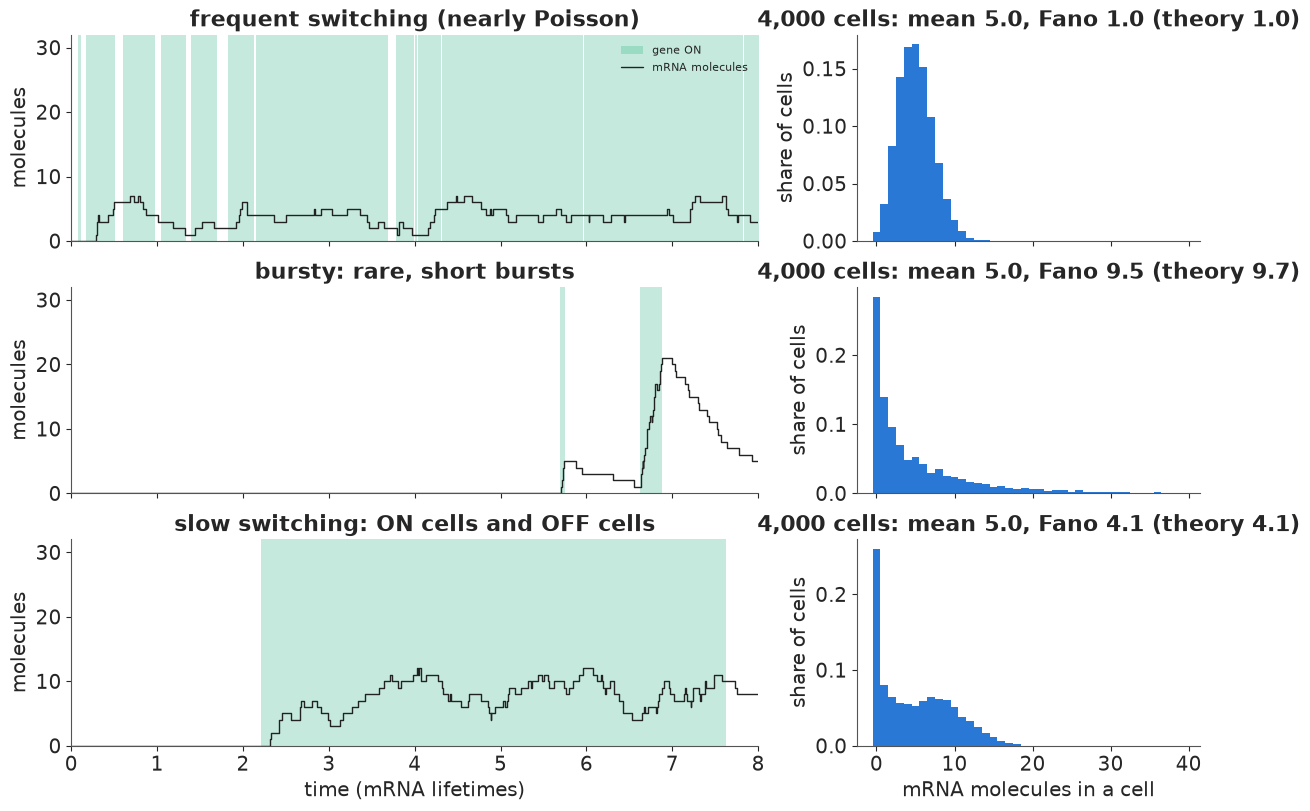

In [2]:
def ssa(kon, koff, ksyn, times, n_cells, rng, g0=0, n0=0):
    """Gillespie SSA of the telegraph model for many independent cells (time in mRNA lifetimes).

    Returns counts n and gene states g at each of `times`, both (len(times), n_cells).
    """
    times = np.asarray(times, float)
    g = np.full(n_cells, g0, dtype=np.int64)
    n = np.full(n_cells, n0, dtype=np.int64)
    t = np.zeros(n_cells)
    j = np.zeros(n_cells, dtype=np.int64)                 # next observation time per cell
    out_n = np.zeros((len(times), n_cells), dtype=np.int64)
    out_g = np.zeros((len(times), n_cells), dtype=np.int64)
    idx = np.arange(n_cells)
    while len(idx):
        gi, ni = g[idx], n[idx]
        r_on, r_off, r_syn, r_deg = kon * (1 - gi), koff * gi, ksyn * gi, ni.astype(float)
        R = r_on + r_off + r_syn + r_deg
        t_new = t[idx] + rng.exponential(1.0 / R)
        while True:                                       # record every observation time passed
            jj = j[idx]
            rec = (jj < len(times)) & (t_new > times[np.minimum(jj, len(times) - 1)])
            if not rec.any():
                break
            c = idx[rec]
            out_n[j[c], c], out_g[j[c], c] = n[c], g[c]
            j[c] += 1
        u = rng.uniform(size=len(idx)) * R
        on, off = u < r_on, (u >= r_on) & (u < r_on + r_off)
        syn = (u >= r_on + r_off) & (u < r_on + r_off + r_syn)
        deg = u >= r_on + r_off + r_syn
        g[idx] = np.where(on, 1, np.where(off, 0, gi))
        n[idx] = ni + syn - deg
        t[idx] = t_new
        idx = idx[j[idx] < len(times)]
    return out_n, out_g


def ssa_path(kon, koff, ksyn, T, rng):
    """One cell's full trajectory: event times, counts and gene states."""
    t, g, n, path = 0.0, 0, 0, [(0.0, 0, 0)]
    while t < T:
        r = np.array([kon * (1 - g), koff * g, ksyn * g, n])
        t += rng.exponential(1 / r.sum())
        e = rng.choice(4, p=r / r.sum())
        g = 1 if e == 0 else (0 if e == 1 else g)
        n += (e == 2) - (e == 3)
        path.append((t, n, g))
    return np.array(path)


def tele_moments(kon, koff, ksyn):
    mean = ksyn * kon / (kon + koff)
    return mean, 1 + ksyn * koff / ((kon + koff) * (1 + kon + koff))


REGIMES = {"frequent switching (nearly Poisson)": (20.0, 2.0, 5.5),
           "bursty: rare, short bursts": (0.5, 10.0, 105.0),
           "slow switching: ON cells and OFF cells": (0.3, 0.3, 10.0)}
snapshots = {k: ssa(*v, [20.0], 4000, rng)[0][0] for k, v in REGIMES.items()}

fig, axes = plt.subplots(3, 2, figsize=(12, 8), width_ratios=[2, 1], sharex="col")
for row, (name, par) in enumerate(REGIMES.items()):
    path = ssa_path(*par, 8.0, np.random.default_rng(RANDOM_SEED + row))
    ax = axes[row, 0]
    ax.fill_between(path[:, 0], 0, path[:, 2] * 32, step="post", color=AQUA, alpha=0.25, lw=0,
                    label="gene ON")
    ax.step(path[:, 0], path[:, 1], where="post", color=INK, lw=1, label="mRNA molecules")
    ax.set(ylim=(0, 32), xlim=(0, 8), ylabel="molecules", title=name)
    x = snapshots[name]
    mean, fano = tele_moments(*par)
    ax = axes[row, 1]
    ax.hist(x, bins=np.arange(-0.5, 40), density=True, color=BLUE)
    ax.set(title=f"4,000 cells: mean {x.mean():.1f}, Fano {x.var() / x.mean():.1f} "
                 f"(theory {fano:.1f})", ylabel="share of cells")
    print(f"{name:40s} kon {par[0]:5.1f} koff {par[1]:5.1f} ksyn {par[2]:6.1f} | burst size "
          f"ksyn/koff {par[2] / par[1]:5.1f} | P(0) {np.mean(x == 0):.2f}")
axes[0, 0].legend(fontsize=8, loc="upper right")
axes[2, 0].set_xlabel("time (mRNA lifetimes)")
axes[2, 1].set_xlabel("mRNA molecules in a cell");

Three genes, the same average of 5 molecules per cell, three different worlds. Left: one cell's
history (green = gene ON). Right: a snapshot of 4,000 cells, which is all an experiment usually
sees; the simulated Fano factors match the formula.

- **Frequent switching** (top): the gene flickers ON and OFF many times per mRNA lifetime; the
  flicker averages out and the counts are almost Poisson (Fano 1).
- **Bursty** (middle): rare ON periods, each short but intense, dump about 10 molecules at once,
  which then decay. Most cells have few molecules, some have 20-30: Fano about 10.
- **Slow switching** (bottom): ON and OFF periods each last about three lifetimes, so the
  population splits into cells whose gene has been OFF for a while (near 0) and cells that have
  been ON (near 10). The snapshot is **bimodal** - no single "typical" cell.

## 2 · The chemical master equation

The probability $P_g(n, t)$ that a cell has gene state $g$ and $n$ molecules obeys the chemical
master equation (CME), one linear ODE per state:

$$\frac{d}{dt}P_0(n) = k_\text{off}P_1(n) - k_\text{on}P_0(n) + (n+1)P_0(n+1) - nP_0(n),$$
$$\frac{d}{dt}P_1(n) = k_\text{on}P_0(n) - k_\text{off}P_1(n) + k_\text{syn}\big(P_1(n-1) - P_1(n)\big)
  + (n+1)P_1(n+1) - nP_1(n).$$

**Finite state projection** (FSP; Munsky & Khammash 2006) keeps the states with $n \le N$: the CME
becomes $\dot p = Q p$ with a $2(N+1)$-square generator $Q$. Then

- the **steady state** solves $Q p = 0$ with $\sum p = 1$: one linear solve (replace one of the
  dependent rows of $Q$ by the normalisation);
- the **time course** from a known start is $p(t) = e^{Qt}p(0)$, a matrix exponential (section 6).

There is also an exact formula: at steady state the telegraph distribution is a **beta-Poisson
mixture** (Peccoud & Ycart 1995; Raj et al. 2006 used it for smFISH counts): the fraction of time
ON behaves like $p \sim \text{Beta}(k_\text{on}, k_\text{off})$ and $n \sim
\text{Poisson}(k_\text{syn} p)$, so
$P(n) = \frac{k_\text{syn}^n}{n!}\frac{(k_\text{on})_n}{(k_\text{on}+k_\text{off})_n}\,
{}_1F_1(k_\text{on}+n;\,k_\text{on}+k_\text{off}+n;\,-k_\text{syn})$. The confluent
hypergeometric function at a large negative argument is an alternating, cancellation-prone series,
so we use it only as a high-precision check (`mpmath`) and as a fast exact sampler (the mixture).

In [3]:
def fsp_generator(kon, koff, ksyn, N, xp=np):
    """Truncated CME generator: dp/dt = Q p, states (OFF, 0..N) then (ON, 0..N)."""
    n = np.arange(N + 1.0)
    I = np.eye(N + 1)
    deg = np.diag(n[1:], 1) - np.diag(n)                          # n -> n - 1 at rate n
    syn = np.eye(N + 1, k=-1) - np.diag(np.r_[np.ones(N), 0.0])   # n -> n + 1 while ON (none at N)
    top = xp.concatenate([deg - kon * I, koff * I], axis=1)
    bottom = xp.concatenate([kon * I, deg - koff * I + ksyn * syn], axis=1)
    return xp.concatenate([top, bottom], axis=0)


def fsp_steady(kon, koff, ksyn, N):
    """P(OFF, n) and P(ON, n), n = 0..N, by one dense linear solve."""
    A = fsp_generator(kon, koff, ksyn, N)
    A[0] = 1.0                                                     # normalisation replaces a row
    p = linalg.solve(A, np.eye(2 * (N + 1))[0])
    return p[:N + 1], p[N + 1:]


def beta_poisson_exact(kon, koff, ksyn, N):
    mpmath.mp.dps = 40
    return np.array([float(mpmath.power(ksyn, n) / mpmath.factorial(n) * mpmath.rf(kon, n)
                           / mpmath.rf(kon + koff, n) * mpmath.hyp1f1(kon + n, kon + koff + n, -ksyn))
                     for n in range(N + 1)])


N_CHECK = 150
for name, par in REGIMES.items():
    p_off, p_on = fsp_steady(*par, N_CHECK)
    exact = beta_poisson_exact(*par, 60)
    print(f"{name:40s} max |FSP - exact| {np.abs((p_off + p_on)[:61] - exact).max():.1e} | "
          f"mass at n = N: {(p_off + p_on)[-1]:.0e} | P(ON) {p_on.sum():.3f} "
          f"(kon/(kon+koff) = {par[0] / (par[0] + par[1]):.3f})")

frequent switching (nearly Poisson)      max |FSP - exact| 5.6e-17 | mass at n = N: 1e-156 | P(ON) 0.909 (kon/(kon+koff) = 0.909)
bursty: rare, short bursts               max |FSP - exact| 5.0e-16 | mass at n = N: 1e-17 | P(ON) 0.048 (kon/(kon+koff) = 0.048)
slow switching: ON cells and OFF cells   max |FSP - exact| 8.3e-16 | mass at n = N: 9e-119 | P(ON) 0.500 (kon/(kon+koff) = 0.500)


FSP agrees with the exact formula to rounding error in all three regimes, and the truncation at
$N = 150$ throws away nothing measurable (the last state carries no mass). The time spent ON is
$k_\text{on}/(k_\text{on}+k_\text{off})$, as it must be.

### A faster exact route: a three-term recurrence, solved the right way

The dense solve costs $O(N^3)$, which matters when a likelihood needs it for many genes and cells
at every gradient step. The generating function $G(z) = \sum_n P(n)z^n$ of the beta-Poisson is
${}_1F_1(k_\text{on}; k_\text{on}+k_\text{off}; k_\text{syn}(z-1))$, which satisfies Kummer's
differential equation. Matching powers of $z$ turns that ODE into a **three-term recurrence** for
the probabilities themselves ($a = k_\text{on}$, $b = k_\text{on}+k_\text{off}$, $k = k_\text{syn}$):

$$k\,(m-1+a)\,P_{m-1} \;-\; m\,(m-1+b+k)\,P_m \;+\; m(m+1)\,P_{m+1} \;=\; 0, \qquad m \ge 1.$$

Running it **forward** from $P_0, P_1$ looks natural and is a disaster: the recurrence has a second,
growing solution, and every rounding error excites it (the probabilities are the **minimal
solution**, the one that decays; Gautschi 1967). Run as a **boundary-value problem** instead: fix
$P_0 = 1$, set $P_{N+1} = 0$ far out in the tail, and solve the $N+1$ equations together. That is
a **tridiagonal** linear system - $O(N)$ work - and normalising at the end gives the pmf. (This is
Miller's and Olver's classic cure for minimal solutions.) We also get the joint distribution for
free: the probability flux up across the cut between $n$ and $n+1$ (transcription, only when ON)
equals the flux down (degradation), so

$$P(\text{ON}, n) = (n+1)\,P(n+1)/k_\text{syn},$$

which section 6 needs for transcription-site data.

frequent switching (nearly Poisson)      max |tridiagonal - dense FSP| 5.6e-17 | TV vs SSA 0.017 (sampling noise alone 0.021)
bursty: rare, short bursts               max |tridiagonal - dense FSP| 5.0e-16 | TV vs SSA 0.035 (sampling noise alone 0.031)
slow switching: ON cells and OFF cells   max |tridiagonal - dense FSP| 5.0e-16 | TV vs SSA 0.018 (sampling noise alone 0.022)
N = 300: dense FSP 2.8 ms, tridiagonal 0.037 ms per pmf


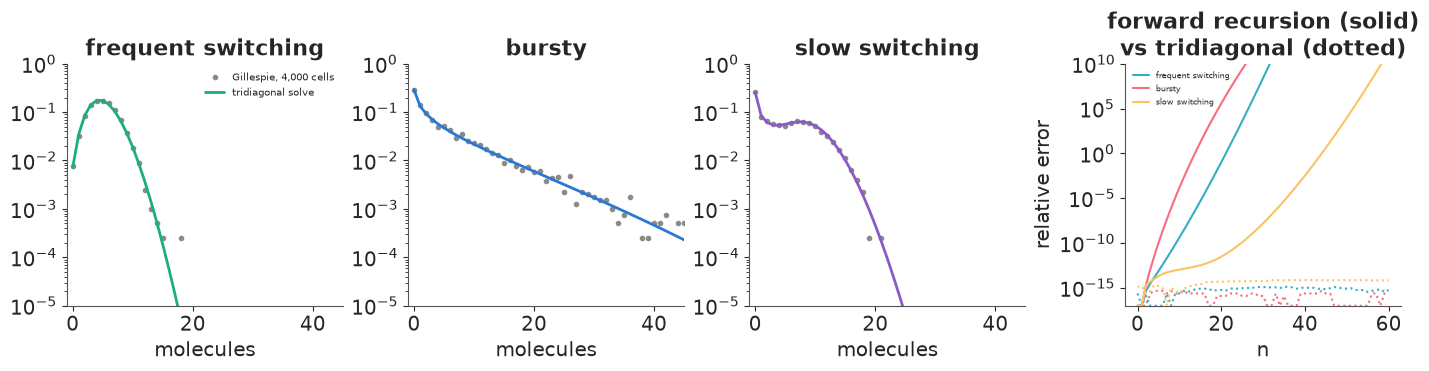

In [4]:
def tele_pmf_np(kon, koff, ksyn, N):
    """Steady-state telegraph pmf on 0..N by the tridiagonal boundary-value solve (NumPy)."""
    a, b, k = kon, kon + koff, ksyn
    m = np.arange(1, N + 1.0)
    ab = np.zeros((3, N + 1))
    ab[0, 1:] = np.r_[0.0, m[:-1] + 1]            # super-diagonal: row m has m + 1 (row 0: none)
    ab[1] = np.r_[1.0, -(m - 1 + b + k)]          # diagonal (row m divided by m)
    ab[2, :-1] = k * (m - 1 + a) / m              # sub-diagonal
    x = linalg.solve_banded((1, 1), ab, np.eye(N + 1)[0])
    return x / x.sum()


def forward_recursion(kon, koff, ksyn, p0, p1, N):
    a, b, k = kon, kon + koff, ksyn
    P = [p0, p1]
    for n in range(N - 1):
        P.append(((n + 1) * (n + b + k) * P[n + 1] - k * (n + a) * P[n]) / ((n + 1) * (n + 2)))
    return np.array(P)


fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, (name, par), c in zip(axes, REGIMES.items(), [AQUA, BLUE, PURPLE]):
    p = tele_pmf_np(*par, N_CHECK)
    emp = np.bincount(snapshots[name], minlength=N_CHECK + 1)[:N_CHECK + 1] / len(snapshots[name])
    tv = 0.5 * np.abs(emp - p).sum()
    ref = np.mean([0.5 * np.abs(np.bincount(rng.choice(N_CHECK + 1, 4000, p=p / p.sum()),
                                            minlength=N_CHECK + 1) / 4000 - p).sum() for _ in range(20)])
    ax.plot(np.arange(N_CHECK + 1), emp, "o", color=GREY, ms=3, label="Gillespie, 4,000 cells")
    ax.plot(np.arange(N_CHECK + 1), p, color=c, lw=2, label="tridiagonal solve")
    ax.set(yscale="log", ylim=(1e-5, 1), xlim=(-1, 45), xlabel="molecules",
           title=name.split(":")[0].split(" (")[0])
    print(f"{name:40s} max |tridiagonal - dense FSP| "
          f"{np.abs(p - sum(fsp_steady(*par, N_CHECK))).max():.1e} | TV vs SSA {tv:.3f} "
          f"(sampling noise alone {ref:.3f})")
axes[0].legend(fontsize=7)
ax = axes[3]
for name, par in REGIMES.items():
    exact = beta_poisson_exact(*par, 60)
    fwd = forward_recursion(*par, exact[0], exact[1], 60)
    ax.semilogy(np.arange(61), np.abs(fwd / exact - 1) + 1e-17, lw=1.5, label=name.split(" (")[0].split(":")[0])
    ax.semilogy(np.arange(61), np.abs(tele_pmf_np(*par, N_CHECK)[:61] / exact - 1) + 1e-17, ls=":",
                color=ax.lines[-1].get_color())
ax.set(xlabel="n", ylabel="relative error", title="forward recursion (solid)\nvs tridiagonal (dotted)",
       ylim=(1e-17, 1e10))
ax.legend(fontsize=6)

A_dense = fsp_generator(0.5, 10.0, 105.0, 300)
t0 = time.perf_counter()
for _ in range(20):
    fsp_steady(0.5, 10.0, 105.0, 300)
t_dense = (time.perf_counter() - t0) / 20
t0 = time.perf_counter()
for _ in range(200):
    tele_pmf_np(0.5, 10.0, 105.0, 300)
t_tri = (time.perf_counter() - t0) / 200
print(f"N = 300: dense FSP {t_dense * 1e3:.1f} ms, tridiagonal {t_tri * 1e3:.3f} ms per pmf")

Three checks. The tridiagonal pmf equals the dense FSP to rounding error; it matches the Gillespie
snapshots, with total-variation distances no larger than 4,000 samples from the pmf itself would
give; and it is far cheaper (timings printed above). The right panel is the cautionary tale:
started from the **exact** $P_0, P_1$, the forward recursion's relative error grows until the
"probabilities" are garbage (and in the bursty regime within about ten steps), while the
boundary-value solve (dotted) stays at rounding level everywhere. Same equation, different
algorithm. (E53 met a related structure - a recursion written as a triangular solve - which was
stable because every term added was positive; here the terms have both signs, and that is what
makes the direction matter.)

In PyTensor the same solve is `pt.linalg.solve(A, e0, assume_a="tridiagonal")`, which is
differentiable, so NUTS can use it.

In [5]:
def tele_logpmf(kon, koff, ksyn, N):
    """PyTensor: steady-state telegraph log-pmf on 0..N; parameters broadcast to a batch shape (...)."""
    a = pt.as_tensor(kon)[..., None]
    b = a + pt.as_tensor(koff)[..., None]
    k = pt.as_tensor(ksyn)[..., None]
    one = pt.ones_like(a + b + k)
    m = np.arange(1, N + 1.0)
    d = pt.concatenate([one, -(m - 1 + b + k)], axis=-1)
    lo = pt.concatenate([0 * one, k * (m - 1 + a) / m], axis=-1)
    up = np.eye(N + 1, k=1) * np.r_[0.0, m[:-1] + 1, 0.0][:, None]
    A = d[..., :, None] * np.eye(N + 1) + lo[..., :, None] * np.eye(N + 1, k=-1) + up
    x = pt.linalg.solve(A, pt.broadcast_to(np.eye(N + 1)[0], d.shape), assume_a="tridiagonal", b_ndim=1)
    return pt.log(x) - pt.log(pt.sum(x, axis=-1, keepdims=True))


_k = pt.dvector("k")
f_check = pytensor.function([_k], tele_logpmf(_k[0], _k[1], _k[2], 80))
print("max |PyTensor - NumPy| (log pmf):",
      f"{np.abs(f_check(np.array([0.5, 10.0, 105.0])) - np.log(tele_pmf_np(0.5, 10.0, 105.0, 80))).max():.1e}")

max |PyTensor - NumPy| (log pmf): 1.8e-15


## 3 · The negative binomial limit, and where it fails

When bursts are short compared with an mRNA lifetime ($k_\text{off} \gg 1$) and rare
($k_\text{off} \gg k_\text{on}$), the Beta$(k_\text{on}, k_\text{off})$ fraction of time ON
becomes a Gamma, and the beta-Poisson becomes a gamma-Poisson: a **negative binomial** with shape
$r = k_\text{on}$ and mean $k_\text{on}B$. That is why the NB is the default model for scRNA-seq
counts, and why its shape parameter is read as a burst frequency. How good is it elsewhere? For a
grid of $(k_\text{on}, k_\text{off})$ with the mean fixed at 5 molecules, we compare the telegraph
with the **best** NB - the one with the same mean and variance - and ask two things: how far
apart the two distributions are (total variation), and whether the NB's shape $r$ still equals the
burst frequency $k_\text{on}$.

slow switching             TV 0.274, NB shape / kon = 5.56
switching once per lifetime TV 0.107, NB shape / kon = 3.06
bursty                     TV 0.027, NB shape / kon = 1.14
share of the grid with TV < 0.05: 0.69


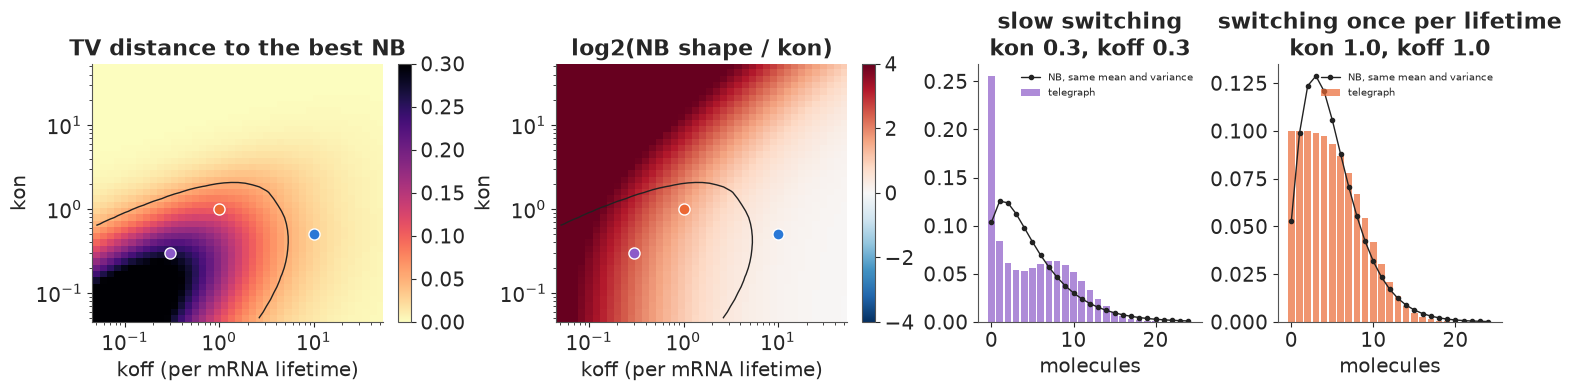

In [6]:
grid = np.logspace(np.log10(0.05), np.log10(50), 41)
MEAN = 5.0
N_MAP = 1500
tv_map = np.zeros((len(grid), len(grid)))
r_map = np.zeros_like(tv_map)
nn = np.arange(N_MAP + 1)
for i, kon in enumerate(grid):
    for j, koff in enumerate(grid):
        ksyn = MEAN * (kon + koff) / kon
        p = tele_pmf_np(kon, koff, ksyn, N_MAP)
        _, fano = tele_moments(kon, koff, ksyn)
        r = MEAN / (fano - 1)                                    # moment-matched NB shape
        q = stats.nbinom.pmf(nn, r, r / (r + MEAN))
        tv_map[i, j] = 0.5 * np.abs(p - q).sum()
        r_map[i, j] = np.log2(r / kon)

EXAMPLES = {"slow switching": (0.3, 0.3), "switching once per lifetime": (1.0, 1.0), "bursty": (0.5, 10.0)}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), width_ratios=[1.3, 1.3, 1, 1])
for ax, z, title, kw in [
        (axes[0], tv_map, "TV distance to the best NB", dict(cmap="magma_r", vmin=0, vmax=0.3)),
        (axes[1], r_map, "log2(NB shape / kon)", dict(cmap="RdBu_r", vmin=-4, vmax=4))]:
    im = ax.pcolormesh(grid, grid, z, shading="nearest", **kw)
    fig.colorbar(im, ax=ax)
    ax.contour(grid, grid, tv_map, levels=[0.05], colors=INK, linewidths=1)
    ax.set(xscale="log", yscale="log", xlabel="koff (per mRNA lifetime)", ylabel="kon", title=title)
    for (lab, (a_, b_)), c in zip(EXAMPLES.items(), [PURPLE, ORANGE, BLUE]):
        ax.plot(b_, a_, "o", color=c, mec="white", ms=8)
for ax, lab in zip(axes[2:], ["slow switching", "switching once per lifetime"]):
    kon, koff = EXAMPLES[lab]
    ksyn = MEAN * (kon + koff) / kon
    p = tele_pmf_np(kon, koff, ksyn, N_MAP)
    _, fano = tele_moments(kon, koff, ksyn)
    r = MEAN / (fano - 1)
    ax.bar(nn[:25], p[:25], color=PURPLE if lab.startswith("slow") else ORANGE, alpha=0.7, label="telegraph")
    ax.plot(nn[:25], stats.nbinom.pmf(nn[:25], r, r / (r + MEAN)), "o-", color=INK, ms=3, lw=1,
            label="NB, same mean and variance")
    ax.set(xlabel="molecules", title=f"{lab}\nkon {kon}, koff {koff}")
    ax.legend(fontsize=7)
for lab, (kon, koff) in EXAMPLES.items():
    i, j = np.argmin(np.abs(grid - kon)), np.argmin(np.abs(grid - koff))
    print(f"{lab:26s} TV {tv_map[i, j]:.3f}, NB shape / kon = {2 ** r_map[i, j]:.2f}")
print(f"share of the grid with TV < 0.05: {np.mean(tv_map < 0.05):.2f}");

Left: the best NB is within 0.05 in total variation (black contour) over about two-thirds of
the plane. It fails in the lower left, where **both** switching rates are below a few per mRNA
lifetime: bursts last about as long as a molecule does, so the snapshot mixes cells that have been
OFF for a while with cells that have been ON. The two examples on the right are inside that
region: the bimodal slow-switching gene (a spike at zero plus a second mode, which the NB replaces
by one skewed hump; TV 0.27), and a gene switching about once per lifetime in each direction (a
flattened, too-wide hump with too many zeros for its mean; TV 0.11).

Middle: even where the NB **fits**, its shape parameter equals the burst frequency only in the
bursty corner (lower right, white). Everywhere else the NB shape is larger than $k_\text{on}$
(red), by a factor of about 3 for the once-per-lifetime gene and 5.6 for the slow-switching one,
and without bound in the frequent-switching region at the top, where the counts are nearly Poisson
and the NB shape runs off to infinity. "NB shape = burst frequency" is a statement about a regime,
not about the NB.

## 4 · The data: allele-resolved mRNA counts in fibroblasts

Larsson et al. (2019) sequenced single primary fibroblasts from an F1 hybrid of two mouse strains
(C57BL/6J x CAST/EiJ). Single-nucleotide differences between the strains let each sequenced
molecule (UMI) be assigned to the **maternal or paternal allele**, so each gene gives two
independent telegraph processes per cell - exactly the one-gene-copy unit the model describes.
They fitted the telegraph model by maximum likelihood to thousands of genes. We take 24 of their
genes, chosen across the range of their switching estimates and with SLAM-seq half-lives
available, and model the C57 allele. Two data decisions:

- **G1 cells only.** After S phase every allele exists twice (sister chromatids), which is a
  different model. The repository's cell-cycle labels leave 165 of the 224 cells.
- **Missing, not zero.** An empty count means the gene was detected but no UMI carried an
  informative SNP; those cells are dropped for that gene (as the txburst README advises).

In [7]:
data.describe("larsson_bursting")
raw = data.load("larsson_bursting")
g1 = raw[raw.phase == "G1"].copy()
cells = g1.groupby("cell", sort=False).allelic_umis.first()
g1["s"] = g1.allelic_umis / cells.mean()                         # per-cell capture/size factor
obs = g1[g1.c57.notna()].copy()
obs["y"] = obs.c57.astype(int)
GENES = obs.groupby("gene", sort=False).y.mean().sort_values().index.tolist()
summary = obs.groupby("gene").agg(cells=("y", "size"), mean=("y", "mean"), var=("y", "var"),
                                  zeros=("y", lambda v: np.mean(v == 0)), max=("y", "max"),
                                  half_life_h=("half_life_h", "first")).loc[GENES]
summary["Fano"] = summary["var"] / summary["mean"]
both = g1[g1.c57.notna() & g1.cast.notna()]
summary["allele_corr"] = both.groupby("gene").apply(
    lambda d: np.corrcoef(d.c57.astype(float), d.cast.astype(float))[0, 1], include_groups=False)
print(f"{len(cells)} G1 cells; allele-assigned UMIs per cell: median {cells.median():,.0f}, "
      f"range {cells.min():,}-{cells.max():,} (CV {cells.std() / cells.mean():.2f})")
print(summary.drop(columns="var").round(2).to_string())

larsson_bursting: Allele-resolved single-cell RNA-seq UMI counts in 224 primary mouse fibroblasts from an F1 hybrid (C57BL/6J x CAST/EiJ), 24 genes, one row per cell x gene: cell; phase (G1, S, G2M, the repository's cell-cycle annotation); allelic_umis (all allele-assigned UMIs of the cell, both alleles, all 10,727 genes: a capture/size factor); gene; c57, cast (UMIs of that gene from each allele; empty = expressed but not assignable to an allele, i.e. missing); half_life_h (mRNA half-life in hours from the repository's SLAM-seq table); txburst_kon, txburst_koff, txburst_ksyn (the repository's published maximum-likelihood telegraph parameters for the C57 allele, in units of the mRNA degradation rate).
  source: Larsson, Johnsson, Hagemann-Jensen, Hartmanis, Faridani, Reinius, Segerstolpe, Rivera, Ren & Sandberg (2019), Genomic encoding of transcriptional burst kinetics, Nature 565:251-254; data files of the paper's GitHub repository sandberg-lab/txburst (data/: SS3_c57_UMIs_concat.csv,

correlation of Dync1h1 with the cell factor: 0.70; median allele correlation 0.30


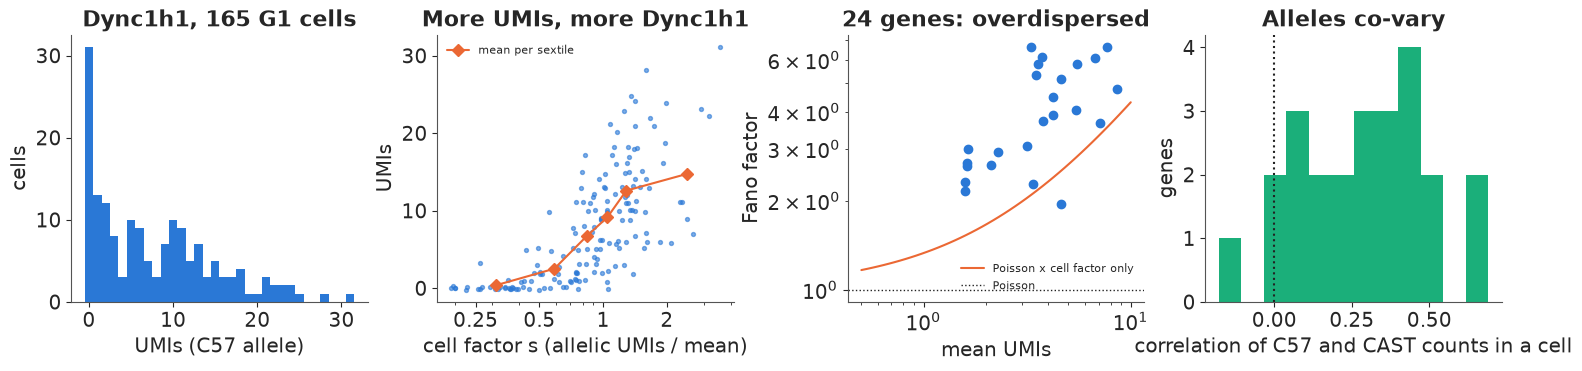

In [8]:
S_ALL = cells.to_numpy() / cells.mean()
dy = obs[obs.gene == "Dync1h1"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
ax = axes[0]
ax.hist(dy.y, bins=np.arange(-0.5, dy.y.max() + 1.5), color=BLUE)
ax.set(xlabel="UMIs (C57 allele)", ylabel="cells", title="Dync1h1, 165 G1 cells")
ax = axes[1]
ax.scatter(dy.s, dy.y + rng.uniform(-0.25, 0.25, len(dy)), s=8, color=BLUE, alpha=0.6)
bins = np.quantile(dy.s, np.linspace(0, 1, 7))
mids = [dy.y[(dy.s >= lo) & (dy.s <= hi)].mean() for lo, hi in zip(bins[:-1], bins[1:])]
ax.plot(0.5 * (bins[1:] + bins[:-1]), mids, "D-", color=ORANGE, label="mean per sextile")
ax.set(xscale="log", xlabel="cell factor s (allelic UMIs / mean)", ylabel="UMIs", title="More UMIs, more Dync1h1")
ax.set_xticks([0.25, 0.5, 1, 2], ["0.25", "0.5", "1", "2"])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.legend(fontsize=8)
ax = axes[2]
cv2 = S_ALL.var() / S_ALL.mean() ** 2
m_line = np.logspace(-0.3, 1, 50)
ax.plot(summary["mean"], summary["Fano"], "o", color=BLUE)
ax.plot(m_line, 1 + cv2 * m_line, color=ORANGE, label="Poisson x cell factor only")
ax.axhline(1, color=INK, ls=":", lw=1, label="Poisson")
ax.set(xscale="log", yscale="log", xlabel="mean UMIs", ylabel="Fano factor", title="24 genes: overdispersed")
ax.legend(fontsize=8)
ax = axes[3]
ax.hist(summary["allele_corr"], bins=12, color=AQUA)
ax.axvline(0, color=INK, ls=":")
ax.set(xlabel="correlation of C57 and CAST counts in a cell", ylabel="genes", title="Alleles co-vary");
print(f"correlation of Dync1h1 with the cell factor: {np.corrcoef(dy.s, dy.y)[0, 1]:.2f}; "
      f"median allele correlation {summary['allele_corr'].median():.2f}")

Every gene is overdispersed (Fano factors of about 2 to 7), as bursting predicts - but the second
and fourth panels are a warning. Cells differ in how many molecules were captured and sequenced:
the total number of allele-assigned UMIs has a coefficient of variation of 0.58 across G1 cells
(the extremes differ almost 20-fold), from differences in cell size and in capture efficiency.
Dync1h1 counts rise steeply with that total (correlation 0.70), and the two alleles of a gene,
which should burst **independently**, are positively correlated in 22 of the 24 genes (median
0.30). Something shared by both alleles of a cell - an **extrinsic** factor, in
the language of Elowitz et al.'s (2002) two-reporter experiment - adds variance. The orange line
shows how much overdispersion the cell factor alone would create for a Poisson gene: a part of,
but not all of, the observed Fano factors. A telegraph model fitted without it will call all of
that variance "bursting".

**Capture efficiency is binomial thinning, and thinning is invisible.** If each molecule is
captured with probability $\varepsilon$, the observed count is $\text{Binomial}(n, \varepsilon)$.
Thinning a Poisson($k_\text{syn}p$) gives Poisson($\varepsilon k_\text{syn}p$), so a thinned
telegraph **is** a telegraph with synthesis rate $\varepsilon k_\text{syn}$ - exactly, not
approximately:

In [9]:
eps, par = 0.3, (0.5, 10.0, 105.0)
p_true = tele_pmf_np(*par, 400)
thin = stats.binom.pmf(np.arange(401)[:, None], np.arange(401)[None, :], eps)   # [observed, true]
print(f"max |thinned telegraph - telegraph with eps * ksyn| = "
      f"{np.abs(thin @ p_true - tele_pmf_np(par[0], par[1], eps * par[2], 400)).max():.1e}")

max |thinned telegraph - telegraph with eps * ksyn| = 2.8e-17


Two consequences. (1) The **absolute** capture efficiency and the synthesis rate are not
identifiable separately from counts: only $\varepsilon k_\text{syn}$ is, so every burst size in
this notebook is in **detected molecules**, a lower bound on the true burst size (it takes spike-in
standards or smFISH calibration to convert). (2) **Relative** capture differences between cells
are identifiable if we have a proxy for them: we give cell $c$ the synthesis rate
$k_\text{syn}s_c$, with $s_c$ its allele-assigned UMIs divided by the average cell. This lumps
capture efficiency with cell size (bigger cells hold more of most mRNAs), which assumes size acts
on the burst size rather than the burst frequency - an assumption, flagged for the exercises.

Each cell now has its own pmf. Solving a system per cell and gene is wasteful, so we solve on a
grid of 12 values of $\log s$ and interpolate the **log-pmf** with 4-point (cubic) Lagrange
weights, which are fixed numbers once the grid is chosen. We check the interpolation error on the
fitted gene below.

In [10]:
N_FIT, N_LEVELS = 90, 12
LOG_S = np.linspace(np.log(S_ALL.min()) - 0.01, np.log(S_ALL.max()) + 0.01, N_LEVELS)


def lagrange_weights(s):
    """Cubic Lagrange weights of log s on the LOG_S grid: base index (node i-1..i+2) and (n, 4) weights."""
    x = (np.log(s) - LOG_S[0]) / (LOG_S[1] - LOG_S[0])
    i = np.clip(np.floor(x).astype(int), 1, N_LEVELS - 3)
    t = x - i
    w = np.stack([-t * (t - 1) * (t - 2) / 6, (t + 1) * (t - 1) * (t - 2) / 2,
                  -(t + 1) * t * (t - 2) / 2, (t + 1) * t * (t - 1) / 6], axis=1)
    return i, w

## 5 · One gene, three likelihoods

We start with Dync1h1 (cytoplasmic dynein heavy chain), the most highly expressed of the 24 genes.
Four models of its 165 counts, all with rates in units of its mRNA degradation rate:

- **Poisson** with mean $\mu s_c$ (constitutive expression plus capture);
- **NB** with shape $k_\text{on}$ and mean $k_\text{on}Bs_c$ (the bursting limit);
- **telegraph** with $(k_\text{on}, k_\text{off}, k_\text{syn}s_c)$, the likelihood of sections 2-4;
- **telegraph without the cell factor** ($s_c = 1$), to see what ignoring it does.

The telegraph is parameterised by what the NB limit says a snapshot should identify: burst
frequency $k_\text{on}$ and burst size $B = k_\text{syn}/k_\text{off}$, plus the burst end rate
$k_\text{off}$. Priors: $\log k_\text{on} \sim N(0, 1.5)$, $\log B \sim N(\log 4, 1.5)$ and
$\log k_\text{off} \sim N(\log 10, 2)$ - bursts lasting from about 1/500 of an mRNA lifetime (a
minute or two, for a 5-hour half-life) to several lifetimes. Each likelihood is a `pm.Potential`
with the per-cell log-likelihood kept as a `Deterministic` for PSIS-LOO (as in E53).

In [11]:
def gene_model(y, s, kind, koff_prior=(np.log(10), 2.0)):
    i0, w = lagrange_weights(s)
    with pm.Model() as model:
        if kind == "Poisson":
            log_mu = pm.Normal("log_mu", 1.0, 1.5)
            ll = pm.logp(pm.Poisson.dist(pt.exp(log_mu) * s), y)
        else:
            log_kon = pm.Normal("log_kon", 0.0, 1.5)
            log_B = pm.Normal("log_B", np.log(4), 1.5)
            if kind == "NB":
                ll = pm.logp(pm.NegativeBinomial.dist(mu=pt.exp(log_kon + log_B) * s,
                                                      alpha=pt.exp(log_kon)), y)
            else:
                log_koff = pm.Normal("log_koff", *koff_prior)
                pm.Deterministic("log_ksyn", log_B + log_koff)
                kon, koff, ksyn = pt.exp(log_kon), pt.exp(log_koff), pt.exp(log_B + log_koff)
                if kind == "telegraph, no cell factor":
                    ll = tele_logpmf(kon, koff, ksyn, N_FIT)[y]
                else:
                    lp = tele_logpmf(kon * np.ones(N_LEVELS), koff * np.ones(N_LEVELS),
                                     ksyn * np.exp(LOG_S), N_FIT)          # (levels, N + 1)
                    ll = sum(w[:, j] * lp[i0 - 1 + j, y] for j in range(4))
        ll = pm.Deterministic("ll", ll)
        pm.Potential("likelihood", ll.sum())
    return model


def fit_gene(model, label, **kw):
    t0 = time.time()
    idata = pm.sample(model=model, random_seed=RANDOM_SEED, progressbar=False, **kw)
    idata["log_likelihood"] = idata.posterior["ll"].to_dataset(name="y")
    idata["posterior"] = idata.posterior.to_dataset().drop_vars("ll")
    loo = az.loo(idata, var_name="y", pointwise=True)
    loo.log_weights = None
    del idata["log_likelihood"]
    print(f"{label:28s} {time.time() - t0:4.0f} s | divergences {int(idata.sample_stats['diverging'].sum()):3d}"
          f" | max r_hat {np.nanmax(az.rhat(idata).to_dataset().to_dataarray().to_numpy()):.3f} | min ess_bulk "
          f"{np.nanmin(az.ess(idata).to_dataset().to_dataarray().to_numpy()):5.0f} | elpd_loo {loo.elpd:7.1f} | "
          f"Pareto k > 0.7: {int((loo.pareto_k > 0.7).sum())}")
    return idata, loo


y_d, s_d = dy.y.to_numpy(), dy.s.to_numpy()
fits, loos = {}, {}
for kind in ["Poisson", "NB", "telegraph", "telegraph, no cell factor"]:
    fits[kind], loos[kind] = fit_gene(gene_model(y_d, s_d, kind), kind, target_accept=0.95)
print(az.compare(loos, round_to=1)[["rank", "elpd", "elpd_diff", "dse", "p"]])

Poisson                         2 s | divergences   0 | max r_hat 1.002 | min ess_bulk  1595 | elpd_loo  -554.2 | Pareto k > 0.7: 0


NB                              1 s | divergences   0 | max r_hat 1.008 | min ess_bulk   434 | elpd_loo  -458.3 | Pareto k > 0.7: 0


telegraph                       6 s | divergences   0 | max r_hat 1.015 | min ess_bulk   414 | elpd_loo  -454.3 | Pareto k > 0.7: 0


telegraph, no cell factor       2 s | divergences   0 | max r_hat 1.005 | min ess_bulk   489 | elpd_loo  -500.5 | Pareto k > 0.7: 0
                           rank   elpd  elpd_diff   dse    p
telegraph                     0 -454.3        0.0   0.0  2.7
NB                            1 -458.3       -4.0   1.8  1.9
telegraph, no cell factor     2 -500.5      -46.3   5.5  3.1
Poisson                       3 -554.2     -100.0  17.5  3.3


In [12]:
def post(idata, var):
    return idata.posterior[var].to_numpy().ravel()


rows = {}
for kind in ["NB", "telegraph", "telegraph, no cell factor"]:
    rows[kind] = {v: f"{np.median(post(fits[kind], v)):.2f} [{np.quantile(post(fits[kind], v), 0.055):.2f}, "
                     f"{np.quantile(post(fits[kind], v), 0.945):.2f}]"
                  for v in ["log_kon", "log_B", "log_koff"] if v in fits[kind].posterior}
print("posterior median [89% interval], natural-log scale")
print(pd.DataFrame(rows).T.fillna("-").to_string())

# interpolation check at the posterior median of the telegraph fit
med = {v: np.exp(np.median(post(fits["telegraph"], v))) for v in ["log_kon", "log_B", "log_koff"]}
kon_m, B_m, koff_m = med["log_kon"], med["log_B"], med["log_koff"]
ll_exact = np.array([np.log(tele_pmf_np(kon_m, koff_m, B_m * koff_m * si, N_FIT)[yi]) for si, yi in zip(s_d, y_d)])
i0, w = lagrange_weights(s_d)
lp_lv = np.log(np.array([tele_pmf_np(kon_m, koff_m, B_m * koff_m * np.exp(l), N_FIT) for l in LOG_S]))
ll_interp = sum(w[:, j] * lp_lv[i0 - 1 + j, y_d] for j in range(4))
print(f"interpolation error of the total log-likelihood: {ll_interp.sum() - ll_exact.sum():+.3f}; "
      f"largest per cell {np.abs(ll_interp - ll_exact).max():.4f}; "
      f"mass beyond N = {N_FIT} for the largest cell factor: "
      f"{tele_pmf_np(kon_m, koff_m, B_m * koff_m * S_ALL.max(), 400)[N_FIT + 1:].sum():.1e}")

posterior median [89% interval], natural-log scale
                                        log_kon              log_B            log_koff
NB                            0.75 [0.45, 1.06]  1.20 [0.89, 1.51]                   -
telegraph                    0.14 [-0.26, 0.65]  2.30 [1.44, 2.84]  0.60 [-0.18, 2.62]
telegraph, no cell factor  -0.60 [-0.86, -0.36]  3.03 [2.66, 3.37]  0.10 [-0.37, 0.72]
interpolation error of the total log-likelihood: -0.035; largest per cell 0.0068; mass beyond N = 90 for the largest cell factor: 4.3e-06


All four fits are clean (no divergences, r_hat at most 1.015, bulk ESS above 400). What the
comparison says:

- **Poisson is out** by 100 units of elpd: Dync1h1 is not expressed constitutively.
- **Leaving out the cell factor costs 46 units** (eight standard errors) - far more than any
  choice between bursting models - and it changes the answer: burst frequency drops by a factor of
  two ($e^{-0.60}$ vs $e^{0.14}$) and burst size doubles, because the spread from cell size and
  capture is booked as bursting.
- **The telegraph edges out the NB** by 4.0 units of elpd, about two standard errors: weak
  evidence that Dync1h1's snapshot is not quite NB-shaped. The telegraph gets it by moving towards
  **long** bursts ($k_\text{off}$ median 1.8 per lifetime: a burst lasting about half an mRNA
  lifetime), with fewer, bigger bursts than the NB's reading ($k_\text{on}$ 1.15 vs 2.1, $B$ 10
  vs 3.3).

The cubic interpolation over the cell factor changes the total log-likelihood by 0.04 and the
truncation at $N = 90$ loses $4 \times 10^{-6}$ of the mass even for the largest cell, both
negligible. Now the geometry of the telegraph posterior.

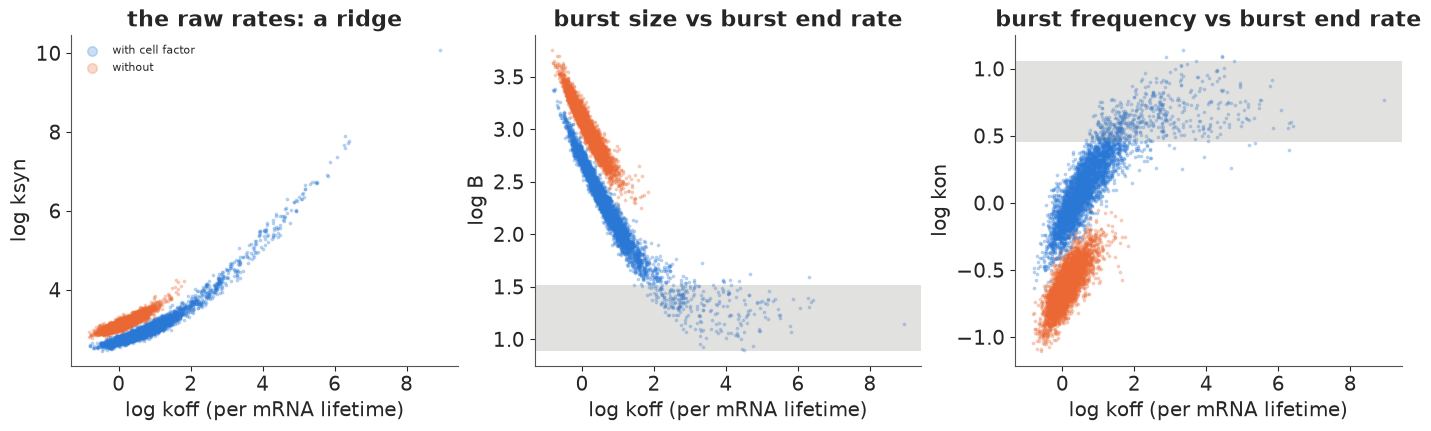

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
tel, tel0 = fits["telegraph"].posterior, fits["telegraph, no cell factor"].posterior
pairs = [("log_koff", "log_ksyn", "the raw rates: a ridge"),
         ("log_koff", "log_B", "burst size vs burst end rate"),
         ("log_koff", "log_kon", "burst frequency vs burst end rate")]
for ax, (xv, yv, title) in zip(axes, pairs):
    ax.scatter(tel[xv].to_numpy().ravel(), tel[yv].to_numpy().ravel(), s=3, alpha=0.25, color=BLUE,
               label="with cell factor")
    ax.scatter(tel0[xv].to_numpy().ravel(), tel0[yv].to_numpy().ravel(), s=3, alpha=0.25, color=ORANGE,
               label="without")
    nb = fits["NB"].posterior
    if yv in nb:
        ax.axhspan(*np.quantile(nb[yv].to_numpy(), [0.055, 0.945]), color=GREY, alpha=0.25, lw=0,
                   label="NB 89% interval")
    ax.set(xlabel="log koff (per mRNA lifetime)", ylabel=yv.replace("_", " "), title=title)
axes[0].legend(fontsize=8, markerscale=4);

Left: in the raw rates the posterior is a curved ridge - $k_\text{off}$ and $k_\text{syn}$ rise
together. Middle and right: in burst coordinates it has two arms. For small $k_\text{off}$ (long
bursts), burst size and frequency trade off steeply against $k_\text{off}$; for large
$k_\text{off}$ the telegraph **is** the NB, burst size and frequency settle on the NB values (grey
bands) and the data say nothing more, so the posterior trails off along the prior. Most of the
mass is on the long-burst arm, but the NB arm is not excluded: the 89% interval of $k_\text{off}$
runs from 0.8 to 14 per lifetime. The cell factor matters here too. Without it (orange) the
posterior sits entirely on the long-burst arm with a **tight** $k_\text{off}$ (0.7-2.1): part of
that "evidence" for slow switching was cell-to-cell variation in capture and size, and the
remaining preference may still be extrinsic noise that one cell factor does not capture. A
snapshot cannot tell us which.

If the data only weakly identify $k_\text{off}$, the prior should be able to move it:

In [14]:
sens = {}
for label, prior in [("default N(log 10, 2)", (np.log(10), 2.0)), ("short bursts N(log 100, 0.5)", (np.log(100), 0.5)),
                     ("long bursts N(log 1, 0.5)", (np.log(1), 0.5))]:
    idata, loo = fit_gene(gene_model(y_d, s_d, "telegraph", koff_prior=prior), label, target_accept=0.95)
    sens[label] = {v: np.median(post(idata, v)) for v in ["log_kon", "log_B", "log_koff"]} | {"elpd_loo": loo.elpd}
    del idata
sens = pd.DataFrame(sens).T
print(sens.assign(kon=np.exp(sens.log_kon), B=np.exp(sens.log_B), koff=np.exp(sens.log_koff))[
    ["kon", "B", "koff", "elpd_loo"]].round(2).to_string())

default N(log 10, 2)            6 s | divergences   0 | max r_hat 1.015 | min ess_bulk   414 | elpd_loo  -454.3 | Pareto k > 0.7: 0


short bursts N(log 100, 0.5)    4 s | divergences   0 | max r_hat 1.003 | min ess_bulk  1044 | elpd_loo  -457.9 | Pareto k > 0.7: 0


long bursts N(log 1, 0.5)       6 s | divergences   0 | max r_hat 1.008 | min ess_bulk   518 | elpd_loo  -453.4 | Pareto k > 0.7: 0
                               kon      B   koff  elpd_loo
default N(log 10, 2)          1.15   9.96   1.82   -454.26
short bursts N(log 100, 0.5)  2.11   3.43  97.03   -457.87
long bursts N(log 1, 0.5)     0.97  12.69   1.27   -453.37


It can, in both directions. A prior insisting on short bursts ($k_\text{off}$ near 100) gets its
way: the fit becomes the NB (burst frequency 2.1, size 3.4) and the LOO score drops by 3.6, to
the NB's value. A prior insisting on bursts as long as an mRNA lifetime is also accepted, with
slightly **better** LOO than the default. Burst size swings from 3.4 to 12.7 detected molecules
across the three priors, because size and $k_\text{off}$ are tied along the ridge; burst
frequency moves by a factor of two. So for Dync1h1 the snapshot identifies the product - the mean
- very well, burst frequency and size only up to the unresolved burst duration, and the duration
itself hardly at all.

## 6 · What would pin down the burst duration? Three simulated experiments

The burst duration $1/k_\text{off}$ is biologically interesting (how long a promoter stays open,
which chromatin and transcription factor residence times control), so what data would measure it?
We simulate 160 cells of a gene at the scale of Dync1h1 - burst frequency 1.5 and burst size 5
per mRNA lifetime, true $k_\text{off} = 3$ (bursts last a third of a lifetime, about 2.4 hours
for Dync1h1's 5-hour half-life) - under three designs:

1. **Snapshot**: counts at steady state, as above.
2. **Snapshot + transcription site**: the same cells, plus whether each cell shows an active
   transcription site (intron or nascent-RNA smFISH shows a bright spot at the gene while it is
   transcribing). The likelihood is the joint $P(g, n)$, which section 2 gave us for free:
   $P(\text{ON}, n) = (n+1)P(n+1)/k_\text{syn}$. (Real transcription-site detection is not
   perfect; we assume it is.)
3. **Induction time course**: the gene is silent with no mRNA until $t = 0$, when a signal turns
   it on; 40 cells are fixed at each of 1/8, 1/4, 1/2 and 1 lifetime (0.9 to 7.3 hours for
   Dync1h1). The likelihood is the FSP time course $e^{Qt}p(0)$: one `pt.linalg.expm` of $Q\,\Delta t$
   and repeated products. This model is compiled with the JAX backend (the expm gradient is
   about twice as fast there).

Measured molecules only (no capture, no cell factor), same priors as section 5.

In [15]:
KON_T, KOFF_T, B_T = 1.5, 3.0, 5.0
KSYN_T = B_T * KOFF_T
sim_rng = np.random.default_rng(RANDOM_SEED + 6)
snap_n, snap_g = (a[0] for a in ssa(KON_T, KOFF_T, KSYN_T, [20.0], 160, sim_rng))
TIMES = np.array([0.125, 0.25, 0.5, 1.0])
tc_n = np.stack([ssa(KON_T, KOFF_T, KSYN_T, [t], 40, sim_rng)[0][0] for t in TIMES])
print(f"snapshot: mean {snap_n.mean():.1f}, Fano {snap_n.var() / snap_n.mean():.1f}, active sites "
      f"{snap_g.mean():.2f} (theory {KON_T / (KON_T + KOFF_T):.2f})")
print("time course, mean per time point:", tc_n.mean(axis=1).round(2), "| max", tc_n.max())

N_SIM = 45


def design_model(design):
    with pm.Model() as model:
        log_kon = pm.Normal("log_kon", 0.0, 1.5)
        log_B = pm.Normal("log_B", np.log(4), 1.5)
        log_koff = pm.Normal("log_koff", np.log(10), 2.0)
        kon, koff, ksyn = pt.exp(log_kon), pt.exp(log_koff), pt.exp(log_B + log_koff)
        if design == "time course":
            E = pt.linalg.expm(fsp_generator(kon, koff, ksyn, N_SIM, xp=pt) * 0.125)
            p, ps = pt.as_tensor(np.eye(2 * (N_SIM + 1))[0]), []
            for steps in [1, 1, 2, 4]:                      # to t = 1/8, 1/4, 1/2, 1
                for _ in range(steps):
                    p = E @ p
                ps.append(p)
            P = pt.stack(ps)
            ll = pt.log(pt.maximum(P[:, :N_SIM + 1] + P[:, N_SIM + 1:], 1e-300))[np.arange(4)[:, None], tc_n]
        else:
            lp = tele_logpmf(kon, koff, ksyn, N_SIM)
            if design == "snapshot":
                ll = lp[snap_n]
            else:                                           # joint (gene state, count)
                nn_ = np.arange(N_SIM)
                log_on = pt.log(nn_ + 1.0) + lp[1:] - pt.log(ksyn)          # log P(ON, n), n < N
                log_off = lp[:-1] + pt.log1mexp(pt.minimum(log_on - lp[:-1], -1e-12))
                ll = pt.where(snap_g == 1, log_on[snap_n], log_off[snap_n])
        pm.Potential("likelihood", ll.sum())
    return model


designs = {}
for design in ["snapshot", "snapshot + transcription site", "time course"]:
    t0 = time.time()
    kw = {"compile_kwargs": {"backend": "jax", "gradient_backend": "jax"}} if design == "time course" else {}
    idata = pm.sample(model=design_model(design), random_seed=RANDOM_SEED, progressbar=False,
                      target_accept=0.9, **kw)
    designs[design] = idata
    q = np.quantile(post(idata, "log_koff"), [0.055, 0.5, 0.945])
    print(f"{design:30s} {time.time() - t0:3.0f} s | divergences {int(idata.sample_stats['diverging'].sum())} | "
          f"max r_hat {float(az.rhat(idata).to_dataset().to_dataarray().max()):.3f} | "
          f"koff median {np.exp(q[1]):.1f}, 89% [{np.exp(q[0]):.1f}, {np.exp(q[2]):.1f}] (truth {KOFF_T})")

snapshot: mean 5.0, Fano 2.6, active sites 0.31 (theory 0.33)
time course, mean per time point: [0.12 0.57 0.95 2.02] | max 9


snapshot                         1 s | divergences 0 | max r_hat 1.011 | koff median 7.2, 89% [1.5, 127.1] (truth 3.0)


snapshot + transcription site    1 s | divergences 0 | max r_hat 1.005 | koff median 4.7, 89% [3.1, 7.3] (truth 3.0)


time course                     33 s | divergences 0 | max r_hat 1.012 | koff median 6.1, 89% [2.1, 42.2] (truth 3.0)


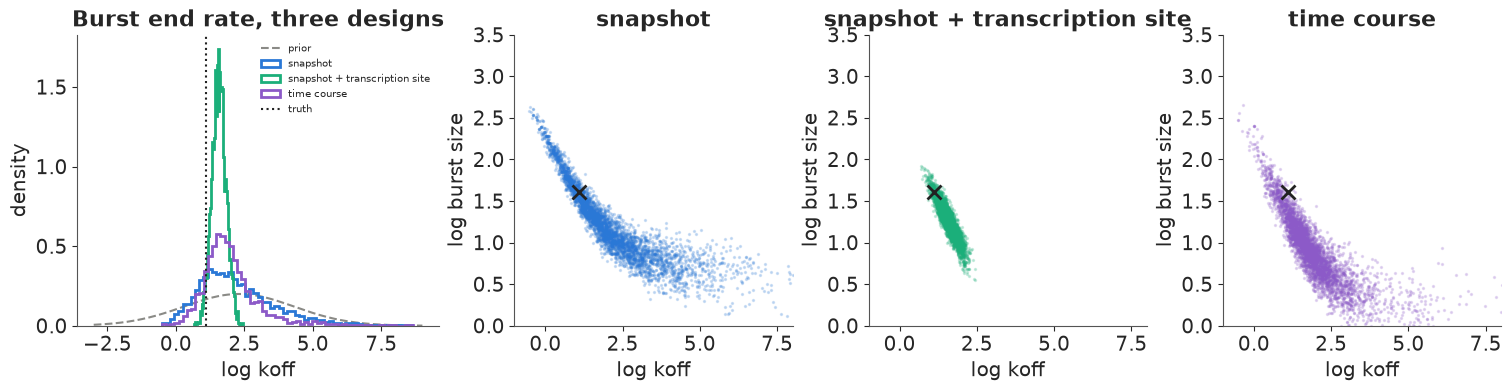

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), width_ratios=[1.3, 1, 1, 1])
ax = axes[0]
xg = np.linspace(-3, 9, 300)
ax.plot(xg, stats.norm.pdf(xg, np.log(10), 2), color=GREY, ls="--", label="prior")
for (design, idata), c in zip(designs.items(), [BLUE, AQUA, PURPLE]):
    ax.hist(post(idata, "log_koff"), bins=60, density=True, histtype="step", lw=2, color=c, label=design)
ax.axvline(np.log(KOFF_T), color=INK, ls=":", label="truth")
ax.set(xlabel="log koff", ylabel="density", title="Burst end rate, three designs")
ax.legend(fontsize=7)
for ax, (design, idata), c in zip(axes[1:], designs.items(), [BLUE, AQUA, PURPLE]):
    ax.scatter(post(idata, "log_koff"), post(idata, "log_B"), s=2, alpha=0.2, color=c)
    ax.plot(np.log(KOFF_T), np.log(B_T), "x", color=INK, ms=10, mew=2)
    ax.set(xlim=(-1, 8), ylim=(0, 3.5), xlabel="log koff", ylabel="log burst size", title=design);

The snapshot alone repeats section 5 in a cleaner setting: $k_\text{off}$ is bounded below
(about 1.5) and runs up into the prior (89% interval up to 127), and burst size slides along with
it (second panel). The **transcription-site** readout changes this completely (green): knowing
which cells are transcribing right now measures the fraction of time ON, $k_\text{on}/(k_\text{on}+
k_\text{off})$, and with the counts fixing the rest that pins $k_\text{off}$ to within a factor of
about 2.4 (3.1-7.3). The true value, 3.0, sits just below that 89% interval - one simulated data
set, and the 160 cells happened to show a slightly low share of active sites (0.31 vs 0.33). The
**induction time course** (purple) helps less: it cuts the upper end of the interval from 127 to
42 but leaves the long NB arm in place. Early time points see the first bursts while they happen,
but with a mean of 0.1-0.6 molecules per cell at the first two times, 40 cells each carry little
information; more cells at early times, or live-cell imaging of single transcription sites, would
do better. The lesson for experiment design: burst **duration** needs data that see the promoter
state or the dynamics; more snapshot cells will not do it.

## 7 · Twenty-four genes: a hierarchical model of burst frequency and size

Larsson et al.'s main question was how burst frequency and burst size vary **across genes** (and
what in the DNA sets them). We fit all 24 genes at once, with the cell factor, and let the genes
share a population distribution:

$$(\log k_{\text{on},g}, \log B_g) \sim \text{MvNormal}(\mu, \Sigma), \qquad
  \log k_{\text{off},g} \sim N(\mu_\text{off}, \sigma_\text{off}),$$

with an LKJ(2) prior on the correlation, HalfNormal(1) scales, $\mu \sim N((0, \log 4), 1)$ and
$\mu_\text{off} \sim N(\log 10, 1.5)$, non-centred. That is 24 genes x 12 cell-factor levels = 288
tridiagonal solves per gradient. PyTensor's `solve(assume_a="tridiagonal")` takes a dense matrix,
so its gradient is dense too - $O(N^2)$ per system. `jax.lax.linalg.tridiagonal_solve` works on
the three diagonals and has an $O(N)$ gradient, so we wrap it with `pytensor.wrap_jax` and compile
the model with the JAX backend.

In [17]:
def tele_logpmf_jax(kon, koff, ksyn):
    """JAX: telegraph log-pmf on 0..N_FIT, batched over the leading dims, via the three diagonals."""
    a, b, k = kon[..., None], (kon + koff)[..., None], ksyn[..., None]
    m = jnp.arange(1, N_FIT + 1.0)
    one = jnp.ones_like(a + b + k)
    d = jnp.concatenate([one, -(m - 1 + b + k)], -1)
    dl = jnp.concatenate([0 * one, k * (m - 1 + a) / m], -1)
    du = jnp.broadcast_to(jnp.concatenate([jnp.zeros(1), m[:-1] + 1, jnp.zeros(1)]), d.shape)
    x = tridiagonal_solve(dl, d, du, jnp.zeros(d.shape + (1,)).at[..., 0, 0].set(1.0))[..., 0]
    return jnp.log(x) - jnp.log(x.sum(-1, keepdims=True))


tele_op = pytensor.wrap_jax(tele_logpmf_jax)
G, L = len(GENES), N_LEVELS
par_test = np.full((G, L), 1.0), np.full((G, L), 4.0), np.full((G, L), 20.0) * np.exp(LOG_S)
f_pt = pytensor.function([], tele_logpmf(*[pt.as_tensor(v) for v in par_test], N_FIT))
print(f"max |JAX op - PyTensor| = {np.abs(tele_op(*[pt.as_tensor(v) for v in par_test]).eval() - f_pt()).max():.1e}")

# gradient timing: PyTensor dense-gradient tridiagonal vs the JAX op
_x = pt.dmatrix("x")
for label, fn in [("PyTensor solve(assume_a='tridiagonal')", lambda a, b, c: tele_logpmf(a, b, c, N_FIT)),
                  ("JAX tridiagonal_solve (wrap_jax)", lambda a, b, c: tele_op(
                      pt.specify_shape(a, (G, L)), pt.specify_shape(b, (G, L)), pt.specify_shape(c, (G, L))))]:
    out = fn(pt.exp(_x), 4.0 * pt.ones_like(_x), 20.0 * pt.exp(_x + LOG_S))[..., :20].sum()
    mode = "JAX" if label.startswith("JAX") else "NUMBA"
    f = pytensor.function([_x], [out, pt.grad(out, _x)], mode=mode)
    x0 = np.zeros((G, L))
    [np.asarray(o) for o in f(x0)]
    t0 = time.perf_counter()
    for _ in range(30):
        [np.asarray(o) for o in f(x0)]
    print(f"{label:40s} {(time.perf_counter() - t0) / 30 * 1e3:.2f} ms per log-pmf + gradient ({G * L} systems)")

max |JAX op - PyTensor| = 2.8e-14


PyTensor solve(assume_a='tridiagonal')   2.35 ms per log-pmf + gradient (288 systems)
JAX tridiagonal_solve (wrap_jax)         0.70 ms per log-pmf + gradient (288 systems)


In [18]:
gi = pd.Index(GENES).get_indexer(obs.gene)
y_all, s_all = obs.y.to_numpy(), obs.s.to_numpy()
i0_all, w_all = lagrange_weights(s_all)
ONES = np.ones((G, L))


def hierarchical_model(kind):
    with pm.Model(coords={"gene": GENES, "par": ["log_kon", "log_B"], "cell_gene": np.arange(len(y_all))}) as model:
        mu = pm.Normal("mu", np.array([0.0, np.log(4)]), 1.0, dims="par")
        packed = pm.LKJCholeskyCov("chol", n=2, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0),
                                   compute_corr=False)
        chol = pm.math.expand_packed_triangular(2, packed, lower=True)
        sd = pm.Deterministic("sd", pt.sqrt(pt.diag(chol @ chol.T)), dims="par")
        pm.Deterministic("rho", (chol @ chol.T)[0, 1] / (sd[0] * sd[1]))
        z = pm.Normal("z", 0.0, 1.0, dims=("gene", "par"))
        theta = pm.Deterministic("theta", mu + z @ chol.T, dims=("gene", "par"))
        kon, B = pt.exp(theta[:, 0]), pt.exp(theta[:, 1])
        if kind == "NB":
            ll = pm.logp(pm.NegativeBinomial.dist(mu=(kon * B)[gi] * s_all, alpha=kon[gi]), y_all)
        else:
            mu_off = pm.Normal("mu_off", np.log(10), 1.5)
            sd_off = pm.HalfNormal("sd_off", 1.0)
            z_off = pm.Normal("z_off", 0.0, 1.0, dims="gene")
            log_koff = pm.Deterministic("log_koff", mu_off + sd_off * z_off, dims="gene")
            koff = pt.exp(log_koff)
            lp = tele_op(pt.specify_shape(kon[:, None] * ONES, (G, L)), pt.specify_shape(koff[:, None] * ONES, (G, L)),
                         pt.specify_shape((B * koff)[:, None] * np.exp(LOG_S), (G, L)))
            ll = sum(w_all[:, j] * lp[gi, i0_all - 1 + j, y_all] for j in range(4))
        ll = pm.Deterministic("ll", ll, dims="cell_gene")
        pm.Potential("likelihood", ll.sum())
    return model


print(f"{len(y_all):,} cell-gene counts, {G} genes")
JAX_KW = {"compile_kwargs": {"backend": "jax", "gradient_backend": "jax"}}
hier, hier_loo = {}, {}
for kind in ["NB", "telegraph"]:
    hier[kind], hier_loo[kind] = fit_gene(hierarchical_model(kind), f"hierarchical {kind}", **JAX_KW)
print(az.compare(hier_loo, round_to=1)[["rank", "elpd", "elpd_diff", "dse", "p"]])
print(az.summary(hier["telegraph"], var_names=["mu", "sd", "rho", "mu_off", "sd_off"], round_to=3))

3,851 cell-gene counts, 24 genes


hierarchical NB                42 s | divergences   0 | max r_hat 1.006 | min ess_bulk   834 | elpd_loo -8588.0 | Pareto k > 0.7: 0


hierarchical telegraph         86 s | divergences   1 | max r_hat 1.015 | min ess_bulk   258 | elpd_loo -8585.4 | Pareto k > 0.7: 0
           rank    elpd  elpd_diff  dse     p
telegraph     0 -8585.4        0.0  0.0  45.5
NB            1 -8588.0       -2.6  2.6  41.1
              mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
mu[log_kon]  0.564  0.113     0.386     0.753   769.924  1088.806  1.010   
mu[log_B]    0.852  0.146     0.615     1.089   761.226  1221.519  1.007   
sd[log_kon]  0.386  0.084     0.264     0.524  1353.590  1820.377  1.004   
sd[log_B]    0.351  0.090     0.220     0.500   792.377  1217.496  1.003   
rho          0.223  0.291    -0.249     0.694   643.171   928.161  1.004   
mu_off       2.598  0.610     1.796     3.695   872.802  1215.776  1.008   
sd_off       0.637  0.378     0.062     1.280   258.446   247.229  1.015   

             mcse_mean  mcse_sd  
mu[log_kon]      0.004    0.002  
mu[log_B]        0.005    0.003  
sd[log_kon]      0.

Both hierarchical fits sample well: the NB with no divergences, the telegraph with one divergence
in 4,000 draws, r_hat at most 1.015 and a lowest bulk ESS of about 260 (for $\sigma_\text{off}$, the
hardest parameter). By LOO over all 3,851 cell-gene counts the telegraph and the NB are
indistinguishable (2.6 units apart, standard error 2.6): once cell-to-cell capture is in the
model, the 24 genes as a group look like bursty genes near the NB regime. Across genes, the burst
frequencies and burst sizes each vary with a population sd of about 0.35-0.4 on the log scale
(a factor of about 1.5 either way), and their correlation is not resolved ($\rho$ 0.22, 89%
interval -0.25 to 0.69).

The population burst end rate needs care. Each gene only weakly constrains $k_\text{off}$; the
hierarchical model combines them into $\mu_\text{off} \approx 2.6$ ($k_\text{off} \approx 13$ per
lifetime, 89% interval about 6-40). That pooling is not innocent: it pulls genes like Dync1h1, whose
own snapshot leaned towards long bursts, onto the NB arm of their ridge, and with it their burst
size (printed below the next figure). Now the per-gene picture, in physical units: the SLAM-seq
half-lives turn a rate per mRNA lifetime into a rate per hour ($k_\text{on}\,\ln 2 / t_{1/2}$).

burst size, posterior / txburst: median ratio 0.59
burst frequency per hour: range of medians 0.12-0.60
txburst ML koff above 100 (per lifetime) for 7 of 24 genes
Dync1h1 in the hierarchical fit: kon 2.05, B 3.9, koff 13.7 (single-gene fit: 1.15, 10.0, 1.8)


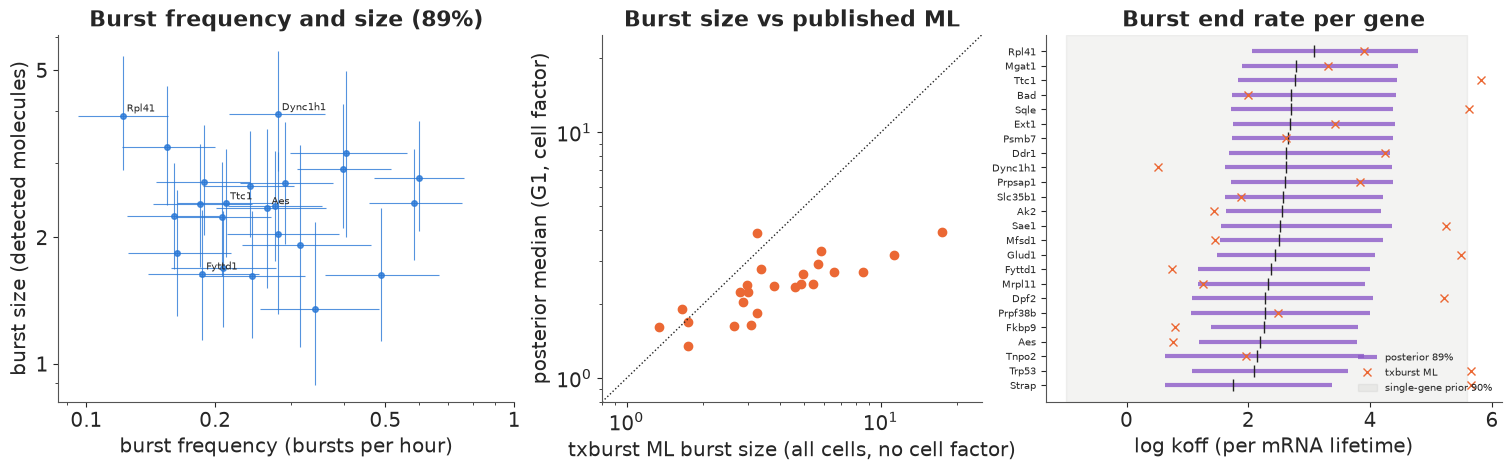

In [19]:
th = hier["telegraph"].posterior["theta"]
kon_g = np.exp(th.sel(par="log_kon").to_numpy().reshape(-1, G))
B_g = np.exp(th.sel(par="log_B").to_numpy().reshape(-1, G))
hl = summary.loc[GENES, "half_life_h"].to_numpy()
freq_h = kon_g * np.log(2) / hl
koff_g = hier["telegraph"].posterior["log_koff"].to_numpy().reshape(-1, G)
txb = raw.groupby("gene").first().loc[GENES]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), width_ratios=[1.2, 1, 1.2])
ax = axes[0]
for arr_x, arr_y in [(freq_h, B_g)]:
    xm, ym = np.median(arr_x, 0), np.median(arr_y, 0)
    xl, xh = np.quantile(arr_x, [0.055, 0.945], 0)
    yl, yh = np.quantile(arr_y, [0.055, 0.945], 0)
    ax.errorbar(xm, ym, xerr=[xm - xl, xh - xm], yerr=[ym - yl, yh - ym], fmt="o", color=BLUE, ms=4,
                elinewidth=0.8, alpha=0.8)
for g, x_, y_ in zip(GENES, xm, ym):
    if g in ("Dync1h1", "Aes", "Rpl41", "Ttc1", "Fyttd1"):
        ax.annotate(g, (x_, y_), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set(xscale="log", yscale="log", xlabel="burst frequency (bursts per hour)",
       ylabel="burst size (detected molecules)", title="Burst frequency and size (89%)")
ax.set_xticks([0.1, 0.2, 0.5, 1], ["0.1", "0.2", "0.5", "1"])
ax.set_yticks([1, 2, 5], ["1", "2", "5"])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax = axes[1]
tx_B = txb.txburst_ksyn / txb.txburst_koff
ax.plot(tx_B, np.median(B_g, 0), "o", color=ORANGE)
lim = [0.8, 25]
ax.plot(lim, lim, color=INK, ls=":", lw=1)
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim, xlabel="txburst ML burst size (all cells, no cell factor)",
       ylabel="posterior median (G1, cell factor)", title="Burst size vs published ML")
ax = axes[2]
order = np.argsort(np.median(koff_g, 0))
lo_, md_, hi_ = np.quantile(koff_g[:, order], [0.055, 0.5, 0.945], 0)
yy = np.arange(G)
ax.hlines(yy, lo_, hi_, color=PURPLE, lw=3, alpha=0.8, label="posterior 89%")
ax.plot(md_, yy, "|", color=INK, ms=8)
ax.plot(np.log(txb.txburst_koff.to_numpy()[order]), yy, "x", color=ORANGE, label="txburst ML")
ax.axvspan(np.log(10) - 1.645 * 2, np.log(10) + 1.645 * 2, color=GREY, alpha=0.1, label="single-gene prior 90%")
ax.set_yticks(yy, np.array(GENES)[order], fontsize=7)
ax.set(xlabel="log koff (per mRNA lifetime)", title="Burst end rate per gene")
ax.legend(fontsize=7, loc="lower right")
print(f"burst size, posterior / txburst: median ratio {np.median(np.median(B_g, 0) / tx_B.to_numpy()):.2f}")
print(f"burst frequency per hour: range of medians {np.median(freq_h, 0).min():.2f}-{np.median(freq_h, 0).max():.2f}")
print(f"txburst ML koff above 100 (per lifetime) for {(txb.txburst_koff > 100).sum()} of {G} genes")
k_d = GENES.index("Dync1h1")
print(f"Dync1h1 in the hierarchical fit: kon {np.median(kon_g[:, k_d]):.2f}, B {np.median(B_g[:, k_d]):.1f}, "
      f"koff {np.exp(np.median(koff_g[:, k_d])):.1f} (single-gene fit: 1.15, 10.0, 1.8)");

Left: burst frequencies (posterior medians) from about one burst every 8 hours to one every 1.7
hours, and burst sizes of 1.3 to 4 **detected** molecules (divide by the unknown capture
efficiency for real molecules), each with wide intervals and no visible relation between the two.
Middle: against the published maximum-likelihood fit - all cells, no cell factor - our burst sizes
are smaller for all but a few genes (median ratio 0.59). Three things contribute: the cell-to-cell
capture and size variation, the doubled alleles in S/G2M cells (both of which the published fit
counts as bursting), and the pooling of $k_\text{off}$ just described - Dync1h1 moves from
$k_\text{on}$ 1.15, $B$ 10, $k_\text{off}$ 1.8 on its own to 2.05, 3.9 and 13.7 in the hierarchy. Right: per-gene $k_\text{off}$
intervals are wide and pooled towards the population, while the published ML values scatter from
below 1 to several hundred per lifetime (above 100 for 7 genes) - point estimates along the flat
ridge of section 5, where the likelihood barely changes.

Finally, two predictive checks of the hierarchical telegraph, with draws from its exact sampler
(the beta-Poisson mixture, given each cell's factor): the share of zeros and the Fano factor of
every gene, and the correlation between the two alleles that the shared cell factor alone predicts
(the CAST allele is not in the model; we simulate a second, independent copy with the same
parameters in the same cell).

share of zero counts                observed inside the 90% interval for 19 of 24 genes; above: Prpsap1, Sae1, Dync1h1, Fkbp9; below: Aes
Fano factor                         observed inside the 90% interval for 21 of 24 genes; above: -; below: Strap, Aes, Rpl41
allele correlation (C57 vs CAST)    observed inside the 90% interval for 14 of 24 genes; above: Sqle, Sae1, Trp53, Ak2, Dync1h1, Fkbp9; below: Tnpo2, Fyttd1, Mrpl11, Rpl41


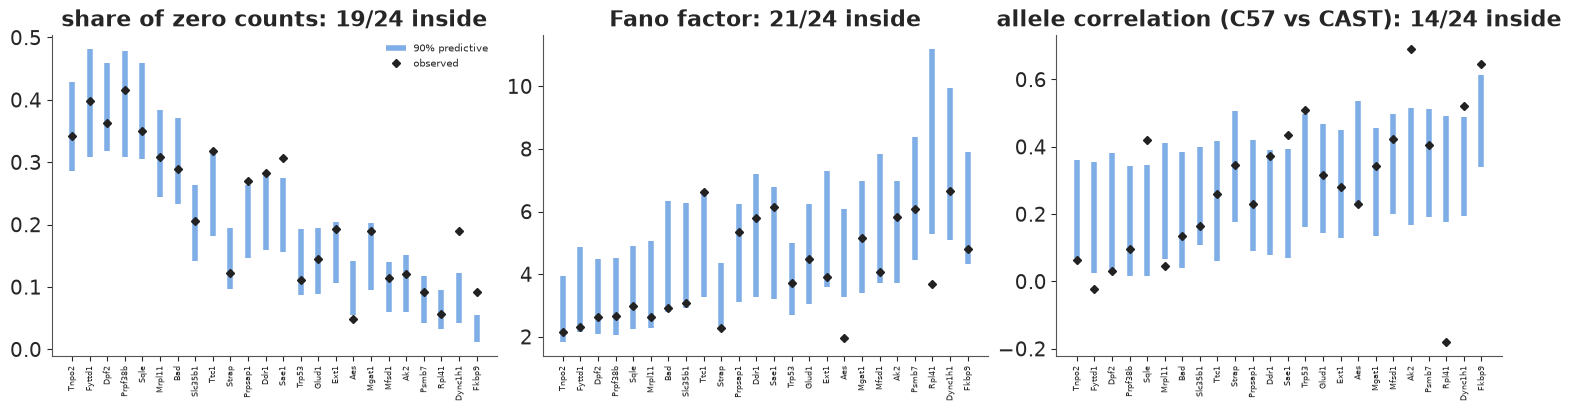

In [20]:
ppc_rng = np.random.default_rng(RANDOM_SEED + 7)
draws = ppc_rng.choice(kon_g.shape[0], 200, replace=False)
koff_lin = np.exp(koff_g)
zero_rep = np.zeros((200, G))
fano_rep = np.zeros((200, G))
corr_rep = np.zeros((200, G))
for d_i, d in enumerate(draws):
    for g_i, g in enumerate(GENES):
        sub = obs[obs.gene == g]
        s_ = sub.s.to_numpy()
        ksyn = B_g[d, g_i] * koff_lin[d, g_i]
        p1 = ppc_rng.beta(kon_g[d, g_i], koff_lin[d, g_i], len(s_))
        p2 = ppc_rng.beta(kon_g[d, g_i], koff_lin[d, g_i], len(s_))
        y1, y2 = ppc_rng.poisson(ksyn * s_ * p1), ppc_rng.poisson(ksyn * s_ * p2)
        zero_rep[d_i, g_i] = np.mean(y1 == 0)
        fano_rep[d_i, g_i] = y1.var() / max(y1.mean(), 1e-9)
        corr_rep[d_i, g_i] = np.corrcoef(y1, y2)[0, 1] if y1.std() > 0 and y2.std() > 0 else 0.0

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, rep, obs_v, title in [(axes[0], zero_rep, summary.loc[GENES, "zeros"].to_numpy(), "share of zero counts"),
                              (axes[1], fano_rep, summary.loc[GENES, "Fano"].to_numpy(), "Fano factor"),
                              (axes[2], corr_rep, summary.loc[GENES, "allele_corr"].to_numpy(),
                               "allele correlation (C57 vs CAST)")]:
    lo_, hi_ = np.quantile(rep, [0.05, 0.95], 0)
    inside = (obs_v >= lo_) & (obs_v <= hi_)
    ax.vlines(np.arange(G), lo_, hi_, color=BLUE, lw=4, alpha=0.6, label="90% predictive")
    ax.plot(np.arange(G), obs_v, "D", color=INK, ms=4, label="observed")
    ax.set_xticks(np.arange(G), GENES, rotation=90, fontsize=6)
    ax.set(title=f"{title}: {inside.sum()}/{G} inside")
    print(f"{title:35s} observed inside the 90% interval for {inside.sum()} of {G} genes; above: "
          f"{', '.join(np.array(GENES)[obs_v > hi_]) or '-'}; below: {', '.join(np.array(GENES)[obs_v < lo_]) or '-'}")
axes[0].legend(fontsize=7);

Zeros and Fano factors are reproduced for most genes (19 and 21 of 24 inside the 90% intervals).
The misses are informative. Dync1h1, Fkbp9, Prpsap1 and Sae1 have **more zeros** than the pooled
model predicts - the signature of long OFF periods that the hierarchy's pooled $k_\text{off}$ has
smoothed away (Dync1h1's own fit wanted them). Aes has fewer zeros and a lower Fano factor, and Aes,
Strap and Rpl41 are less variable than predicted: for them the cell factor seems to add variance
that is not there.

The third panel is an independent check, because the CAST allele was never used in the fit: the
shared cell factor alone predicts a positive allele correlation, and it matches 14 of 24 genes.
Six genes (Sqle, Sae1, Trp53, Ak2, Dync1h1, Fkbp9) have alleles that co-vary **more** than capture
and size explain - something else shared by the two alleles of a cell (position within G1, a shared
transcription factor) is at work, extrinsic noise that a single-allele model would count as
bursting. Four (Tnpo2, Fyttd1, Mrpl11, Rpl41) co-vary **less**, so a single cell factor acting on
every gene's burst size is too crude for them; Rpl41, a ribosomal protein gene, is even negatively
correlated between alleles.

## Summary

- The **telegraph model** (a gene switching ON/OFF, transcribing when ON) produces Poisson,
  bursty or bimodal snapshots depending on how fast the promoter switches relative to mRNA decay;
  Gillespie's algorithm simulates it exactly (section 1).
- Its **chemical master equation** truncated by **FSP** gives the steady state by one linear solve
  and a time course by a matrix exponential. For the steady state a **three-term recurrence**
  derived from Kummer's equation is exact and $O(N)$ - provided it is solved as a **tridiagonal
  boundary-value problem**; run forward it explodes (section 2).
- The **negative binomial** is the telegraph's short-burst limit. The best NB fits most of the
  parameter plane but fails for slow switching, and its shape parameter is a burst frequency only
  in the bursty corner (section 3).
- **Capture efficiency** is binomial thinning, which is exactly a smaller $k_\text{syn}$: burst
  sizes are in detected molecules; per-cell capture differences matter and are modelled with a
  cell factor. For Dync1h1, leaving it out cost 46 units of elpd - far more than NB vs telegraph -
  halved the burst frequency, doubled the burst size and made the burst duration look precisely
  measured (sections 4-5).
- **A snapshot pins down the mean well, but burst frequency and size only up to the burst
  duration, and the duration hardly at all**: a curved ridge whose short-burst arm is the NB limit,
  and a $k_\text{off}$ that follows its prior (pair plots, prior sensitivity). A
  **transcription-site** readout pins $k_\text{off}$; a small **induction time course** only trims
  the ridge (section 6).
- A **hierarchical** model across 24 genes (JAX tridiagonal solve via `wrap_jax`, 4x faster
  gradients) gives burst frequencies of one per 1.7-8 hours and sizes of 1-4 detected molecules,
  smaller than the published fit. Pooling $k_\text{off}$ moves individual genes along their ridges;
  predictive checks of zeros, Fano factors and the unused second allele show where the cell
  factor and the pooling fall short (section 7).

## Try it yourself

1. **Allelic differences.** Fit the CAST allele too, with gene x allele parameters, and ask for
   which genes the two alleles differ in burst frequency or size - Larsson et al.'s question about
   cis-regulatory variation. Which of the two parameters differs more often between alleles?
2. **Where does the cell factor act?** We scaled the synthesis rate (burst size) by $s_c$. Scale
   the burst frequency instead ($k_\text{on}s_c$, capture then acts separately as thinning with a
   second factor), or estimate an exponent $s_c^\gamma$ on each. Compare by LOO, and see how the
   burst-frequency-vs-size picture of section 7 changes.
3. **Imperfect transcription-site detection.** In section 6, detect an active site only with
   probability $q$ (a mixture over the true gene state). How fast does the $k_\text{off}$ posterior
   degrade as $q$ drops from 1 to 0.5, and what if $q$ is unknown? Compare with doubling the
   number of time points in the induction design.